#1. 애플망고-그을음병 병징 영역 추출

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
이미지 로드 성공!


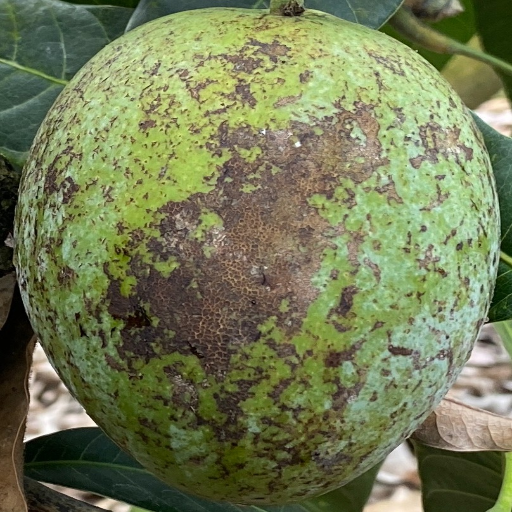

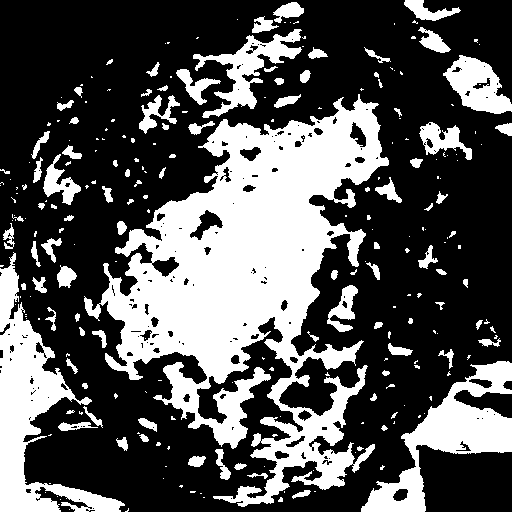

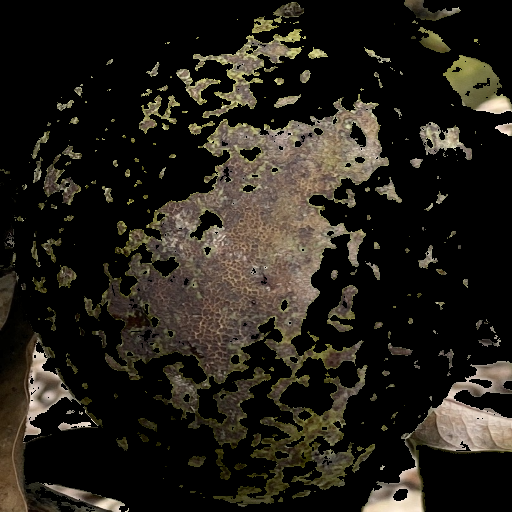

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

import cv2
import numpy as np
from google.colab.patches import cv2_imshow  # Colab 이미지 출력 함수

# 1. 이미지 로드
image_path = '/content/gdrive/My Drive/Colab Notebooks/data/병징3.jpg'  # 과실 이미지 경로
image = cv2.imread(image_path)

if image is None:
    print("이미지 로드 실패!")
    exit()
else:
    print("이미지 로드 성공!")

# 2. 이미지 크기 조정 (분석 및 테스트를 위해 축소)
resized_image = cv2.resize(image, (512, 512))

# 3. HSV 색공간 변환
hsv_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2HSV)

# 4. 병징 영역 추출을 위한 통합 HSV 범위 설정
# 검은색, 갈색, 흰색 모두 포함하는 HSV 범위
lower_bound = np.array([0, 30, 0])       # 낮은 범위 (Hue 0부터 시작)
upper_bound = np.array([30, 255, 255])   # 높은 범위 (Value 최대치까지)

# 병징 영역 마스크 생성
disease_mask = cv2.inRange(hsv_image, lower_bound, upper_bound)

# 5. 병징 영역만 추출
# 원본 이미지에 병징 영역 마스크를 결합하여 병징 부분만 추출
disease_area = cv2.bitwise_and(resized_image, resized_image, mask=disease_mask)

# 6. 배경제거 (병징이 아닌 모든 부분을 검은색으로 변경)
background_removed = cv2.bitwise_and(resized_image, resized_image, mask=disease_mask)

# 7. 결과 시각화
cv2_imshow(resized_image)    # 원본 이미지
cv2_imshow(disease_mask)     # 병징 마스크
cv2_imshow(disease_area)     # 병징 영역만 추출한 이미지